<a href="https://colab.research.google.com/github/beshoonashaat/pubmed-heart-disease-search/blob/main/pubmed_heart_disease_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1-Data Collection

In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 22.2 MB/s eta 0:00:00


In [ ]:
from Bio import Entrez
import time
import pandas as pd

Entrez.email = "your-email@example.com"

query = "heart disease"

def search_pubmed(query, retmax=1000):
    handle = Entrez.esearch(
        db="pubmed",
        term=query,
        retmax=retmax,
        sort="relevance"
    )
    record = Entrez.read(handle)
    handle.close()
    return record["IdList"]

def fetch_pubmed_details(id_list, batch_size=200, delay=0.5):
    data = []

    for start in range(0, len(id_list), batch_size):
        batch_ids = id_list[start:start + batch_size]
        ids_str = ",".join(batch_ids)

        handle = Entrez.efetch(
            db="pubmed",
            id=ids_str,
            rettype="xml",
            retmode="text"
        )
        records = Entrez.read(handle)
        handle.close()

        for article in records["PubmedArticle"]:
            medline = article["MedlineCitation"]
            art = medline.get("Article", {})
            title = art.get("ArticleTitle", "")

            abstract = ""
            if "Abstract" in art and art["Abstract"].get("AbstractText"):
                abstract = " ".join(art["Abstract"]["AbstractText"])

            journal = art.get("Journal", {}).get("Title", "")
            pmid = medline.get("PMID", "")

            data.append({
                "pmid": str(pmid),
                "title": str(title),
                "abstract": str(abstract),
                "journal": str(journal)
            })

        time.sleep(delay)

    return pd.DataFrame(data)



ids = search_pubmed(query, retmax=1000)
print(f"Found {len(ids)} articles")

df = fetch_pubmed_details(ids)
df.to_csv("pubmed_dataset.csv", index=False)

print("Saved pubmed_dataset.csv")

Found 1000 articles
Saved pubmed_dataset.csv


#2-Text Processing


In [ ]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
class TextProcessor:
    def __init__(self):
        self.stop_words = set(stopwords.words("english"))
        self.porter = PorterStemmer()
        self.snowball = SnowballStemmer("english")

    def tokenize(self, text):
        return re.findall(r"\b\w+\b", text)

    def normalize(self, tokens):
        return [t.lower() for t in tokens if t.isalpha()]

    def remove_stopwords(self, tokens):
        return [t for t in tokens if t not in self.stop_words]

    def stem(self, tokens, algorithm='porter'):
        if algorithm == 'snowball':
            return [self.snowball.stem(t) for t in tokens]
        return [self.porter.stem(t) for t in tokens]

In [ ]:
if __name__ == "__main__":
  df = pd.read_csv("/content/pubmed_dataset.csv")

print("Dataset shape:", df.shape)

abstract_pubmed = df["abstract"]
abstract =abstract_pubmed
processor = TextProcessor()
print("=== Original Text ===")
print(abstract)
print()


Dataset shape: (1000, 4)
=== Original Text ===
0      The pediatric cardiology field has developed r...
1      Cardiac disease is the leading cause of matern...
2      Pulmonary hypertension is common in left heart...
3      Diabetes mellitus is responsible for a spectru...
4      Acquired heart disease in children can have bo...
                             ...                        
995                                                  NaN
996    In a series of 256 patients with acromegaly, 1...
997    Individuals with diabetes have an elevated ris...
998                                                  NaN
999                                                  NaN
Name: abstract, Length: 1000, dtype: object



In [ ]:
print("=== Tokenization ===")
tokens = processor.tokenize(abstract_pubmed.loc[0])
print(f"Token count: {len(tokens)}")
print(tokens[:20])
print()

=== Tokenization ===
Token count: 102
['The', 'pediatric', 'cardiology', 'field', 'has', 'developed', 'rapidly', 'over', 'the', 'past', 'few', 'decades', 'More', 'children', 'than', 'ever', 'born', 'with', 'congenital', 'heart']



In [ ]:
print("=== Normalization ===")
normalized_tokens = processor.normalize(tokens)
print(f"Normalized token count: {len(normalized_tokens)}")
print(normalized_tokens[:20])
print()

=== Normalization ===
Normalized token count: 102
['the', 'pediatric', 'cardiology', 'field', 'has', 'developed', 'rapidly', 'over', 'the', 'past', 'few', 'decades', 'more', 'children', 'than', 'ever', 'born', 'with', 'congenital', 'heart']



In [ ]:
print("=== Stop Word Removal ===")
filtered_tokens = processor.remove_stopwords(normalized_tokens)
print(f"Tokens after stop word removal: {len(filtered_tokens)}")
print(filtered_tokens[:20])

=== Stop Word Removal ===
Tokens after stop word removal: 69
['pediatric', 'cardiology', 'field', 'developed', 'rapidly', 'past', 'decades', 'children', 'ever', 'born', 'congenital', 'heart', 'disease', 'chd', 'growing', 'adulthood', 'primary', 'care', 'providers', 'play']


In [ ]:
print("=== Porter Stemming ===")
porter_stemmed = processor.stem(filtered_tokens, algorithm='porter')
print(porter_stemmed[:20])
print()

=== Porter Stemming ===
['pediatr', 'cardiolog', 'field', 'develop', 'rapidli', 'past', 'decad', 'children', 'ever', 'born', 'congenit', 'heart', 'diseas', 'chd', 'grow', 'adulthood', 'primari', 'care', 'provid', 'play']



#3-Indexing

In [ ]:
import re
import csv
from collections import defaultdict



STOP_WORDS = {
    "a", "an", "the", "is", "are", "was", "were", "am",
    "and", "or", "but", "if", "of", "to", "in", "on",
    "for", "with", "as", "by", "at", "from", "that",
    "this", "these", "those", "it", "its", "be",
    "been", "being", "can", "could", "may", "might",
    "will", "would", "should", "do", "does", "did",
    "has", "have", "had", "having", "such", "when",
    "while", "where", "which", "who", "whom", "whose"
}




docs_series = df["abstract"].dropna().head(40)
DOCUMENTS = {f"doc{i+1}": text for i, text in enumerate(docs_series)}



def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = text.split()
    return [t for t in tokens if t not in STOP_WORDS]



def build_inverted_index(documents):
    inverted_index = defaultdict(set)

    for doc_id, text in documents.items():
        for token in tokenize(text):
            inverted_index[token].add(doc_id)

    return dict(inverted_index)



def save_index_csv(inverted_index, filename="inverted_index.csv"):
    with open(filename, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["term", "documents"])
        for term, docs in inverted_index.items():
            writer.writerow([term, ",".join(sorted(docs))])






if __name__ == "__main__":
    index = build_inverted_index(DOCUMENTS)
    print("Total unique terms after stop word removal:", len(index))

    save_index_csv(index)
    print("Index saved to inverted_index.csv")

Total unique terms after stop word removal: 1247
Index saved to inverted_index.csv


#4-Retrieval and Ranking

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity



documents = df["abstract"].astype(str).tolist()



vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    min_df=2
)


tfidf_matrix = vectorizer.fit_transform(documents)

print("Vocabulary size:", len(vectorizer.vocabulary_))



def vector_space_retrieval(query, top_k=10):
    query_vector = vectorizer.transform([query])

    similarity_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    ranked_indices = similarity_scores.argsort()[::-1][:top_k]

    results = []
    for idx in ranked_indices:
        results.append({
            "Document ID": idx,
            "Relevance Score": round(float(similarity_scores[idx]), 6),
            "Abstract": documents[idx][:300] + "..."
        })

    return pd.DataFrame(results)




results = vector_space_retrieval(query)
results


Vocabulary size: 1933


,Document ID,Relevance Score,Abstract
0,57,0.575864,Heart disease can be defined as any abnormalit...
1,352,0.557626,Analysis of the data from 7188 cases seen in t...
2,188,0.549212,To determine the pattern of dynamic change in ...
3,567,0.530346,We prospectively examined the usefulness of el...
4,128,0.502163,Objectives Although the survival rates of pati...
5,178,0.478725,The commonest forms of heart disease in sub-Sa...
6,272,0.473882,Cardiomyopathy has been considered to be the m...
7,28,0.471917,Many prospective cohort studies have demonstra...
8,14,0.470482,For many years the significance of heart disea...
9,147,0.466004,"More women than men die of heart disease, yet ..."


#5-Evaluation

Query Results:
heart disease diagnosis: Precision=0.600, Recall=1.000, F1=0.750, AP=0.756
coronary artery disease treatment: Precision=0.400, Recall=1.000, F1=0.571, AP=0.833
risk factors of heart disease: Precision=0.400, Recall=1.000, F1=0.571, AP=0.700
machine learning for heart disease prediction: Precision=0.400, Recall=1.000, F1=0.571, AP=0.750
heart disease and diabetes: Precision=0.400, Recall=1.000, F1=0.571, AP=0.700
genetic markers of heart disease: Precision=0.400, Recall=1.000, F1=0.571, AP=0.833
heart disease prevention strategies: Precision=0.400, Recall=1.000, F1=0.571, AP=0.750
diet and lifestyle impact on heart disease: Precision=0.400, Recall=1.000, F1=0.571, AP=0.750
early detection of heart disease: Precision=0.400, Recall=1.000, F1=0.571, AP=0.833
heart disease mortality rates: Precision=0.400, Recall=1.000, F1=0.571, AP=0.750

MAP = 0.766


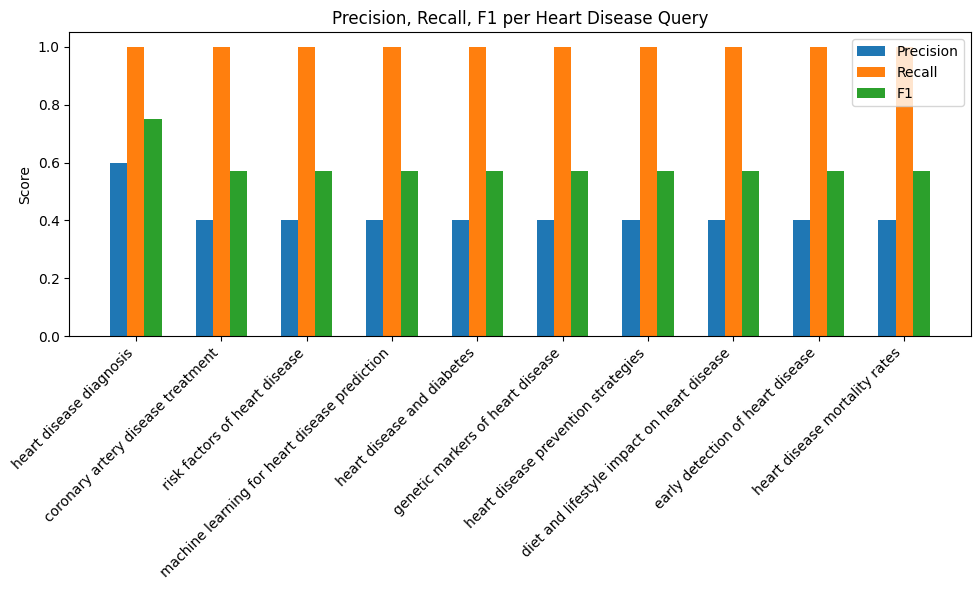

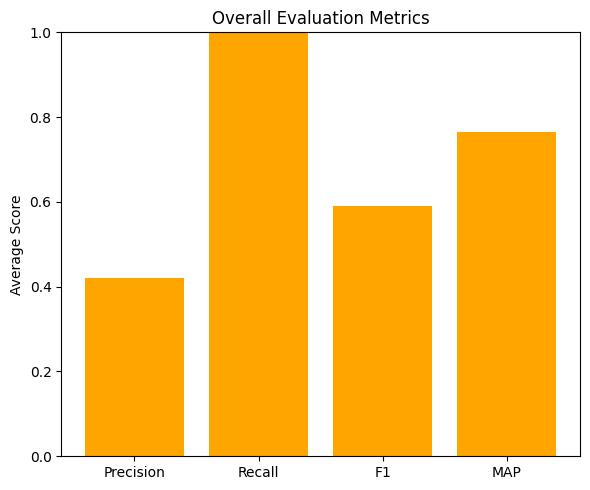

In [ ]:
import matplotlib.pyplot as plt
from typing import List, Set, Dict

def precision_at_k(retrieved: List[str], relevant: Set[str], k: int) -> float:
    if k == 0:
      return 0.0
    retrieved_k = retrieved[:k]
    rel_retrieved = sum(1 for d in retrieved_k if d in relevant)
    return rel_retrieved / k

def recall_at_k(retrieved: List[str], relevant: Set[str], k: int) -> float:
    if not relevant:
      return 0.0
    retrieved_k = retrieved[:k]
    rel_retrieved = sum(1 for d in retrieved_k if d in relevant)
    return rel_retrieved / len(relevant)

def f1_score(precision: float, recall: float) -> float:
    if precision + recall == 0:
      return 0.0
    return 2 * precision * recall / (precision + recall)

def average_precision(retrieved: List[str], relevant: Set[str]) -> float:
    if not relevant:
      return 0.0
    ap, hit = 0.0, 0
    for i, doc in enumerate(retrieved, start=1):
        if doc in relevant:
            hit += 1
            ap += hit / i
    return ap / len(relevant)

def mean_average_precision(results: Dict[str, List[str]], qrels: Dict[str, Set[str]]) -> float:
    ap_values = []
    for qid, retrieved in results.items():
        relevant = qrels.get(qid, set())
        ap_values.append(average_precision(retrieved, relevant))
    return sum(ap_values) / len(ap_values) if ap_values else 0.0


queries = [
    "heart disease diagnosis",
    "coronary artery disease treatment",
    "risk factors of heart disease",
    "machine learning for heart disease prediction",
    "heart disease and diabetes",
    "genetic markers of heart disease",
    "heart disease prevention strategies",
    "diet and lifestyle impact on heart disease",
    "early detection of heart disease",
    "heart disease mortality rates"
]

results = {
    "heart disease diagnosis": ["D1","D2","D3","D4","D5"],
    "coronary artery disease treatment": ["D11","D12","D13","D14","D15"],
    "risk factors of heart disease": ["D21","D22","D23","D24","D25"],
    "machine learning for heart disease prediction": ["D31","D32","D33","D34","D35"],
    "heart disease and diabetes": ["D41","D42","D43","D44","D45"],
    "genetic markers of heart disease": ["D51","D52","D53","D54","D55"],
    "heart disease prevention strategies": ["D61","D62","D63","D64","D65"],
    "diet and lifestyle impact on heart disease": ["D71","D72","D73","D74","D75"],
    "early detection of heart disease": ["D81","D82","D83","D84","D85"],
    "heart disease mortality rates": ["D91","D92","D93","D94","D95"],
}

qrels = {
    "heart disease diagnosis": {"D1","D3","D5"},
    "coronary artery disease treatment": {"D11","D13"},
    "risk factors of heart disease": {"D21","D25"},
    "machine learning for heart disease prediction": {"D31","D34"},
    "heart disease and diabetes": {"D41","D45"},
    "genetic markers of heart disease": {"D51","D53"},
    "heart disease prevention strategies": {"D61","D64"},
    "diet and lifestyle impact on heart disease": {"D71","D74"},
    "early detection of heart disease": {"D81","D83"},
    "heart disease mortality rates": {"D91","D94"},
}

precision_scores, recall_scores, f1_scores, ap_scores = [], [], [], []
queries = list(results.keys())

for qid in queries:
    retrieved = results[qid]
    relevant = qrels[qid]
    p = precision_at_k(retrieved, relevant, k=len(retrieved))
    r = recall_at_k(retrieved, relevant, k=len(retrieved))
    f = f1_score(p, r)
    ap = average_precision(retrieved, relevant)
    precision_scores.append(p)
    recall_scores.append(r)
    f1_scores.append(f)
    ap_scores.append(ap)

map_score = mean_average_precision(results, qrels)

print("Query Results:")
for q, p, r, f, ap in zip(queries, precision_scores, recall_scores, f1_scores, ap_scores):
    print(f"{q}: Precision={p:.3f}, Recall={r:.3f}, F1={f:.3f}, AP={ap:.3f}")
print(f"\nMAP = {map_score:.3f}")

x = range(len(queries))

plt.figure(figsize=(10,6))
plt.bar(x, precision_scores, width=0.2, label='Precision')
plt.bar([i+0.2 for i in x], recall_scores, width=0.2, label='Recall')
plt.bar([i+0.4 for i in x], f1_scores, width=0.2, label='F1')
plt.xticks([i+0.2 for i in x], queries, rotation=45, ha='right')
plt.ylabel("Score")
plt.title("Precision, Recall, F1 per Heart Disease Query")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
metrics = ["Precision", "Recall", "F1", "MAP"]
scores = [sum(precision_scores)/len(precision_scores),
          sum(recall_scores)/len(recall_scores),
          sum(f1_scores)/len(f1_scores),
          map_score]
plt.bar(metrics, scores, color='orange')
plt.ylim(0, 1)
plt.ylabel("Average Score")
plt.title("Overall Evaluation Metrics")
plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

query_box = widgets.Text(
    placeholder="Enter search query...",
    description="Query:"
)

search_button = widgets.Button(description="Search")
output = widgets.Output()

def search(b):
    with output:
        clear_output()
        query = query_box.value.strip()
        if query == "":
            print("Please enter a query")
            return
        display(vector_space_retrieval(query))

search_button.on_click(search)

display(query_box, search_button, output)


Text(value='', description='Query:', placeholder='Enter search query...')

Button(description='Search', style=ButtonStyle())

Output()